In [16]:
from qutip import*
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import krotov as kt 

In [2]:
#kets en la base computacional
ket_0, ket_1 = basis(2,0), basis(2,1)

# Valores esperados
sigma_00=ket_0*ket_0.dag() #sigma |0><0| 
sigma_11=ket_1*ket_1.dag() #sigma |1><1|
sigma_10=ket_1*ket_0.dag() #sigma |1><0| 
sigma_z = ket_0*ket_0.dag() - ket_1*ket_1.dag() #sigma z
sigma_x = ket_0*ket_1.dag() + ket_1*ket_0.dag() #sigma x

#Estados al aplicar Hadamard
Hadamard=(sigma_x+sigma_z)/np.sqrt(2)

H_Objetivo_1 = Hadamard*sigma_00*Hadamard.dag()
H_Objetivo_2 = Hadamard*sigma_11*Hadamard.dag()

#objetive_2= Qobj(np.array([[1/2,-1/2],
#                        [-1/2,1/2]]), dims=[[2], [2]])

#Constantes
w_0 = 1.0  # Frecuencia de resonancia
h = 1.0   # Constante de Planck reducida

# **Calculos necesarios para entender el funcional del articulo**

In [3]:
#Estados predefinidos para la funcional "3states" de compuertas

def rho1(basis_states):
    """State ρ₁ from the "3states" functional"""
    d = len(basis_states)  # dimension of logical subspace
    return sum(
        [
            (2 * (d - i) / (d * (d + 1))) * psi * psi.dag()
            for (i, psi) in enumerate(basis_states)
            # note that i is 0-based, unlike in the paper
        ]
    )
    
def rho2(basis_states):
    """State ρ₂ from the "3states" functional"""
    d = len(basis_states)  # dimension of logical subspace
    return (1.0 / d) * sum(
        [
            psi_i * psi_j.dag()
            for (psi_i, psi_j) in itertools.product(basis_states, repeat=2)
        ]
    )
    
def rho3(basis_states):
    """State ρ₃ from the "3states" functional"""
    d = len(basis_states)  # dimension of logical subspace
    return (1.0 / d) * sum([psi * psi.dag() for psi in basis_states])

In [4]:
# Article Optimal control theory for a unitary operation under dissipative evolution
n_qubit = 2
ket01 = qutip.ket((0, 1), dim=(n_qubit, n_qubit))
ket00 = qutip.ket((0, 0), dim=(n_qubit, n_qubit))
ket10 = qutip.ket((1, 0), dim=(n_qubit, n_qubit))
ket11 = qutip.ket((1, 1), dim=(n_qubit, n_qubit))
basis = [ket00, ket01, ket10, ket11]

In [5]:
#pureza para rho_1
purity_1=(rho1(basis)**2).tr()

#pureza para rho_2
purity_2=(rho2(basis)**2).tr()

#pureza para rho_3
purity_3=(rho3(basis)**2).tr()

purities=[purity_1, purity_2, purity_3]

In [6]:
#pesos asociados a cada estado del articulo
weight_1=20
weight_2=1
weight_3=1
weights=[weight_1, weight_2, weight_3]

# **Normalizacion de pesos**
$$\omega^{*}_j=\omega_j\dfrac{[\omega_1, \omega_2, \cdots, \omega_i]}{\sum_{i}^n\omega_i}$$

In [7]:
pd.DataFrame({'weights':weights, 'purity':purities, 'weights/purity':[weights[0]/purities[0], weights[1]/purities[1], weights[2]/purities[2]], 'weights/purity(3/22)':[(3/22)*weights[0]/purities[0], weights[1]/purities[1]*(3/22),weights[2]/purities[2]*(3/22)]} )


,weights,purity,weights/purity,weights/purity(3/22)
0,20,0.30,66.666667,9.090909
1,1,1.00,1.000000,0.136364
2,1,0.25,4.000000,0.545455


In [8]:
w = np.array([20, 1, 1], dtype=np.float64)
w *= len(w) / np.sum(w) # manual normalization
w /= np.array([0.3, 1.0, 0.25])

In [9]:
weights

[20, 1, 1]

# **A. State preparation**

In [10]:
#Definimos la funcion inicial para el control
def guess_control (t, _=None):
    A= 1e-2    #Amplitud del modelo de control cuantico
    return A*np.vectorize(kt.shapes.flattop)(t, t_start =times[0], t_stop =times[-1], t_rise =times[-1]/30, func = "sinsq")

# Tiempo de la evolucion del sistema
times=np.linspace(0.0,10.0,500)

#Definimos ahora el hamiltoniano del sistema
H0=-h*w_0*sigma_z
H1=h*w_0*sigma_x
H=[H0,[H1,guess_control]]

#Definimos el hamiltoniano con forma de liouvillian
H_L=kt.objectives.liouvillian(H, c_ops=[])

In [ ]:
#Establecemos la tarea cuantica para el control cuantico
task_H=[kt.Objective(initial_state=sigma_00, target=H_Objetivo_1, H=H_L)]

#task_H2=[kt.Objective(initial_state=ket_0, target=Hadamard*ket_0, H=H)]
#task=kt.gate_objectives(basis_states=[ket_0, ket_1], gate=Hadamard, H=H ,)

In [ ]:
#Definimos ahora la funcion S(t) para la fase de actualizacion del control
def S(t):
  return np.vectorize(kt.shapes.flattop)(t , t_start =times[0] , t_stop =times[-1] , t_rise =times[-1]/30 , func = "sinsq")

#Parámetros de Krotov
pulse_options= {guess_control: dict(lambda_a=1000, update_shape=S)}

In [56]:
    # Ejecutar la optimización
optimized_result = kt.optimize_pulses(
        task_H,
        pulse_options= pulse_options,
        tlist=times,
        propagator=kt.propagators.DensityMatrixODEPropagator(reentrant=True),  
        #propagator=kt.propagators.expm, # Método de propagación (exponencial matricial)
        chi_constructor=kt.functionals.chis_re,  # Condición adjunta (final time)
        #iter_stop=20,  # Número de iteraciones
        info_hook=kt.info_hooks.print_table(J_T=kt.functionals.J_T_re),  # Mostrar progreso, providing J_T explicitly
        check_convergence = kt.convergence.Or(
        kt.convergence.value_below ('1e-3', name ='J_T') ,
        kt.convergence.check_monotonic_error,), store_all_pulses = True,)


iter.      J_T    ∫gₐ(t)dt          J       ΔJ_T         ΔJ  secs
0     5.01e-01    0.00e+00   5.01e-01        n/a        n/a     0
1     4.99e-01    1.20e-03   5.00e-01  -2.39e-03  -1.20e-03     0
2     4.97e-01    1.20e-03   4.98e-01  -2.39e-03  -1.20e-03     0
3     4.94e-01    1.20e-03   4.95e-01  -2.39e-03  -1.20e-03     0
4     4.92e-01    1.20e-03   4.93e-01  -2.39e-03  -1.20e-03     0
5     4.89e-01    1.20e-03   4.91e-01  -2.39e-03  -1.20e-03     0
6     4.87e-01    1.20e-03   4.88e-01  -2.39e-03  -1.20e-03     0
7     4.85e-01    1.20e-03   4.86e-01  -2.39e-03  -1.20e-03     0
8     4.82e-01    1.20e-03   4.83e-01  -2.39e-03  -1.19e-03     0
9     4.80e-01    1.20e-03   4.81e-01  -2.39e-03  -1.19e-03     0
10    4.77e-01    1.20e-03   4.79e-01  -2.39e-03  -1.19e-03     0
11    4.75e-01    1.20e-03   4.76e-01  -2.39e-03  -1.19e-03     0
12    4.73e-01    1.19e-03   4.74e-01  -2.39e-03  -1.19e-03     0
13    4.70e-01    1.19e-03   4.71e-01  -2.39e-03  -1.19e-03     0
14    4.68

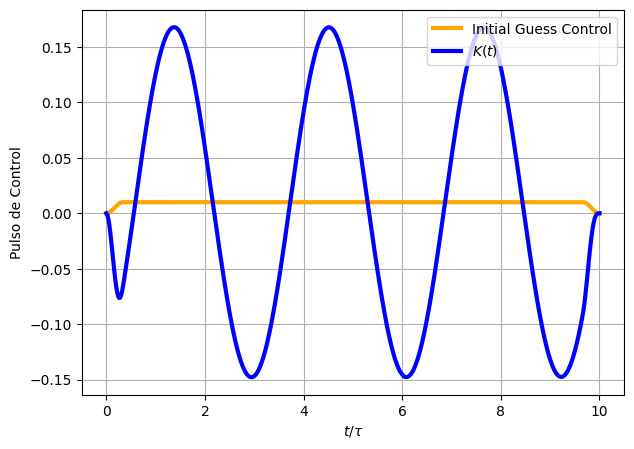

In [57]:
# Campo de control optimizado
optimized_pulse = optimized_result.optimized_controls[0]

plt.figure(figsize=(7, 5))
plt.plot(times, guess_control(times), 'orange', linewidth=3, label="Initial Guess Control")
plt.plot(times, optimized_pulse, 'b', linewidth=3, label=r"$K(t)$")
plt.xlabel(r'$t/\tau$')
plt.ylabel("Pulso de Control")
plt.legend()
#plt.ylim(-0.6,0.6)
plt.grid()
plt.show()


# **Dinamica estado $\ket{0}$**

In [58]:
#valores esperados
e_ops = [sigma_00 , sigma_11 , sigma_10]

result = optimized_result.optimized_objectives[0].mesolve (times,rho0=sigma_00,e_ops=e_ops )

# Dinámica cerrada para calcular la fidelidad
result_= optimized_result.optimized_objectives[0].mesolve (times,e_ops=[]) #Dinamica cerrada con control

fidelidad_DC=[]

#Fidelidad en cada instante de tiempo
for estado in range(len(times)):
    fidelidad_DC.append(fidelity(result_.states[estado],H_Objetivo_1))

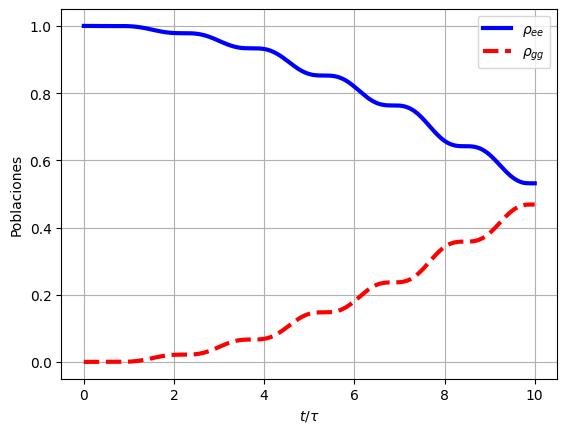

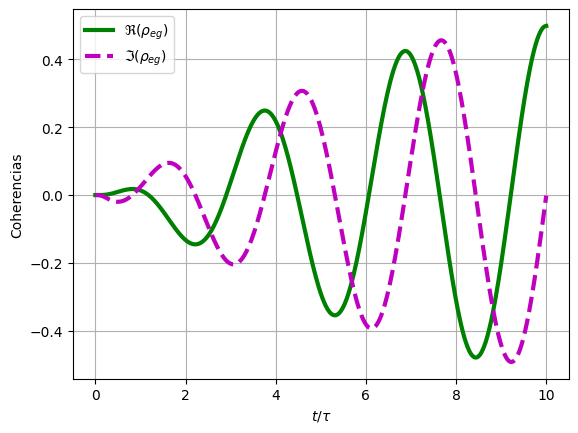

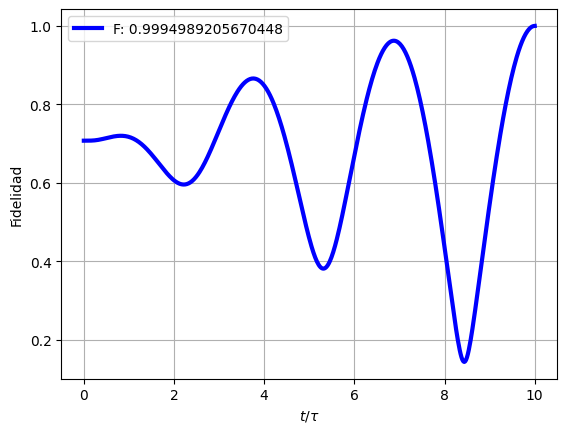

In [59]:

# Dinamica  cuantica del sistema

ig, ax = plt.subplots()
ax.plot(result.times, result.expect[0], 'b', linewidth=3)
ax.plot(result.times, result.expect[1],'--r', linewidth=3)
ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel('Poblaciones')
ax.legend((r'$\rho_{ee}$', r'$\rho_{gg}$'))
plt.grid()
plt.show()

# Coherencias
ig, ax = plt.subplots()
ax.plot(result.times, result.expect[2].real, 'g', linewidth=3)
ax.plot(result.times, result.expect[2].imag, '--m', linewidth=3 )
ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel('Coherencias')
ax.legend((r'$\Re(\rho_{eg})$',r'$\Im(\rho_{eg})$'))
plt.grid()
plt.show()

# Grafica de la fidelidad en función del tiempo
plt.plot(times, fidelidad_DC, 'b', linewidth=3, label=f"F: {fidelidad_DC[-1]}")
plt.xlabel(r'$t/\tau$')
plt.ylabel('Fidelidad')
plt.legend()
plt.grid()
plt.show()


# **Dinamica cerrada con pure dephasing**

In [65]:
#Operador de disipación
Lz=sigma_z

#Rango de valores de las tasa de disipacion
Gamma=np.linspace(0,0.1e-1,10)

In [66]:
#Resolvemos la dinamica para cada gamma
fidelidad_PD_k = []

for i, gamma_pdg in enumerate(Gamma):
    c_ops_PD_k=[np.sqrt(gamma_pdg+0j)*Lz]
    result_PD_k=optimized_result.optimized_objectives[0].mesolve (times,c_ops=c_ops_PD_k, e_ops=[])
    fidelidad_PD_k.append(result_PD_k.states)

In [67]:
fidelidad_PD_k_1 = []
for estado in range(len(Gamma)):
    fidelidad_PD_k_1.append(fidelity(fidelidad_PD_k[estado][-1], H_Objetivo_1))


/tmp/ipykernel_38945/1741454742.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


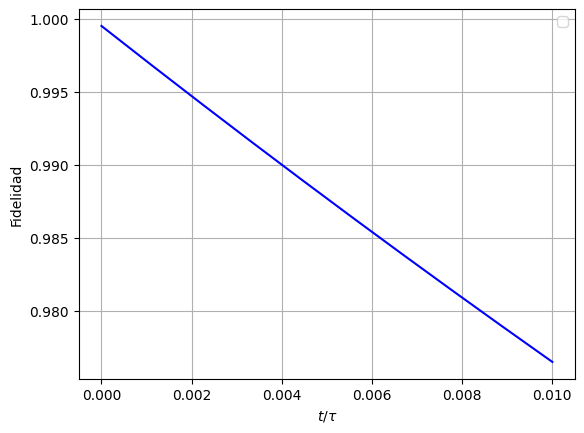

In [68]:
# Grafica de la fidelidad en función del tiempo
plt.plot(Gamma, fidelidad_PD_k_1, 'b')
plt.xlabel(r'$t/\tau$')
plt.ylabel('Fidelidad')
plt.legend()
plt.grid()
plt.show()

# **Dinamica cerrada con amplitude damping**

In [69]:
#Operador de disipación
LA=sigmam()

In [70]:
#Resolvemos la dinamica para cada gamma
fidelidad_AD_k = []

for i, gamma_pdg in enumerate(Gamma):
    c_ops_AD_k=[np.sqrt(gamma_pdg+0j)*LA]
    result_AD_k=optimized_result.optimized_objectives[0].mesolve (times,c_ops=c_ops_AD_k, e_ops=[])
    fidelidad_AD_k.append(result_AD_k.states)

In [71]:
fidelidad_AD_k_1 = []
for estado in range(len(Gamma)):
    fidelidad_AD_k_1.append(fidelity(fidelidad_AD_k[estado][-1], H_Objetivo_1))


/tmp/ipykernel_38945/3140044963.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


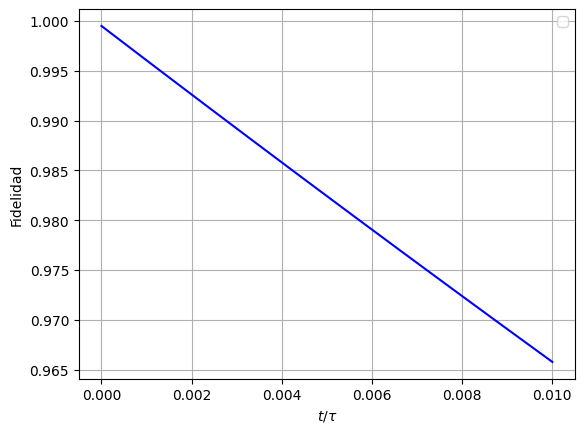

In [72]:
# Grafica de la fidelidad en función del tiempo
plt.plot(Gamma, fidelidad_AD_k_1, 'b')
plt.xlabel(r'$t/\tau$')
plt.ylabel('Fidelidad')
plt.legend()
plt.grid()
plt.show()

# **A. Gate preparation**

In [11]:
#Definimos el conjunto de estados iniciales del sistema
psi_0=sigma_00
psi_1=sigma_11
psi_2= Qobj(np.array([[1/2,1/2],
                        [1/2,1/2]]), dims=[[2], [2]])

#Definimos los pesos asociados a cada estado
w1=w2=w3=1/3

#Calculamos la pureza de cada estado
P_1=(psi_0**2).tr()
P_2=(psi_1**2).tr()
P_3=(psi_2**2).tr()

#Relcacion peso/pureza
WP_1=w1/P_1
WP_2=w2/P_2
WP_3=w3/P_3

In [ ]:
#Establecemos la tarea cuantica como compuerta (Esta es la forma de Krotov para definir compuertas cuanticas como tareas cuanticas)
#La desventaja de usar este metodo, es que en su forma original solo admite la base computacional en la dimension de la compuerta
# y otros conjuntos de estados en particular. Para usar otros estados y darles pesos (w), se nesecita modificar el metodo.
task=kt.gate_objectives(basis_states=[ket_0, ket_1], gate=Hadamard, H=H_L ,liouville_states_set='fanchini', weights=[WP_1, WP_2, WP_3], normalize_weights=True)

#Por experimentar, asi se define la tarea cuantica de los estados pero en la forma de transiciones de estados con pesos iguales. (w1=w2=w3=1)
task2=[kt.Objective(initial_state=sigma_00, target=H_Objetivo_1, H=H_L), kt.Objective(initial_state=sigma_11, target=H_Objetivo_2, H=H_L), kt.Objective(initial_state=H_Objetivo_1, target=sigma_00, H=H_L)]

#Definimos ahora la funcion S(t) para la fase de actualizacion del control
def S(t):
    return np.vectorize(kt.shapes.flattop)(t , t_start =times[0] , t_stop =times[-1] , t_rise =times[-1]/30 , func = "sinsq")

#Parámetros de Krotov
pulse_options= {guess_control: dict(lambda_a=100, update_shape=S)}

In [83]:
    # Ejecutar la optimización
optimized_result_gate = kt.optimize_pulses(
        task,
        pulse_options= pulse_options,
        tlist=times,
        propagator=kt.propagators.DensityMatrixODEPropagator(reentrant=True),  
        #propagator=kt.propagators.expm, # Método de propagación (exponencial matricial)
        chi_constructor=kt.functionals.chis_re,  # Condición adjunta (final time)
        info_hook=kt.info_hooks.print_table(J_T=kt.functionals.J_T_re),  # Mostrar progreso, providing J_T explicitly
        #iter_stop=10,
        check_convergence = kt.convergence.Or(
        kt.convergence.value_below ('1e-3', name ='J_T') ,
        kt.convergence.check_monotonic_error,), store_all_pulses = True
        )

iter.      J_T    ∫gₐ(t)dt          J       ΔJ_T         ΔJ  secs
0     5.01e-01    0.00e+00   5.01e-01        n/a        n/a     1
1     4.92e-01    4.59e-03   4.97e-01  -9.17e-03  -4.58e-03     2
2     4.83e-01    4.58e-03   4.88e-01  -9.16e-03  -4.58e-03     3
3     4.74e-01    4.57e-03   4.78e-01  -9.14e-03  -4.57e-03     3
4     4.65e-01    4.55e-03   4.69e-01  -9.10e-03  -4.55e-03     3
5     4.56e-01    4.52e-03   4.60e-01  -9.04e-03  -4.52e-03     3
6     4.47e-01    4.49e-03   4.51e-01  -8.97e-03  -4.48e-03     2
7     4.38e-01    4.44e-03   4.42e-01  -8.88e-03  -4.44e-03     2
8     4.29e-01    4.39e-03   4.33e-01  -8.78e-03  -4.38e-03     3
9     4.20e-01    4.33e-03   4.25e-01  -8.66e-03  -4.33e-03     2
10    4.12e-01    4.27e-03   4.16e-01  -8.53e-03  -4.26e-03     2
11    4.03e-01    4.20e-03   4.08e-01  -8.39e-03  -4.19e-03     3
12    3.95e-01    4.12e-03   3.99e-01  -8.24e-03  -4.12e-03     3
13    3.87e-01    4.04e-03   3.91e-01  -8.08e-03  -4.04e-03     3
14    3.79

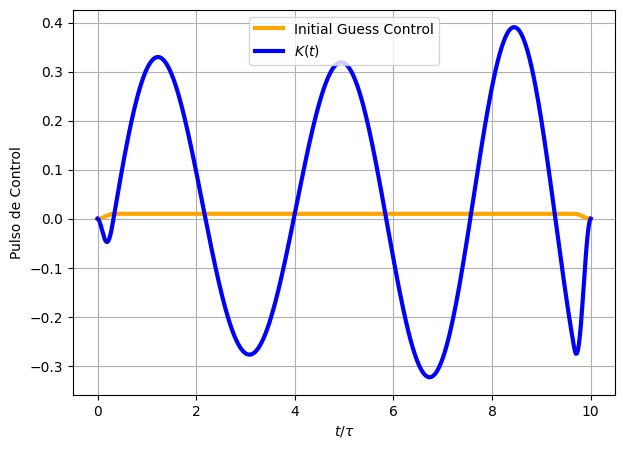

In [84]:
# Campo de control optimizado
optimized_pulse_gate = optimized_result_gate.optimized_controls[0]

plt.figure(figsize=(7, 5))
plt.plot(times, guess_control(times), 'orange', linewidth=3, label="Initial Guess Control")
plt.plot(times, optimized_pulse_gate, 'b', linewidth=3, label=r"$K(t)$")
plt.xlabel(r'$t/\tau$')
plt.ylabel("Pulso de Control")
plt.legend()
#plt.ylim(-0.6,0.6)
plt.grid()
plt.show()
